# 📓 Notebook: Support Vector Machine (SVM) from Scratch


## Part 1: Introduction and Margin Concept


### Theory
The main idea behind SVM is finding the optimal decision boundary (hyperplane) that separates two classes. Not just any boundary, but the one with the **Maximum Margin**.

*   **Margin**: The distance between the decision boundary and the closest data points of each class.
*   **Support Vectors**: The specific data points that lie on the edge of the margin. They "support" or define the boundary.

**Why Maximum Margin?**
A larger margin provides better generalization to unseen data. It reduces the risk of overfitting.

### Visualization
Let's visualize a simple dataset and the concept of a margin.

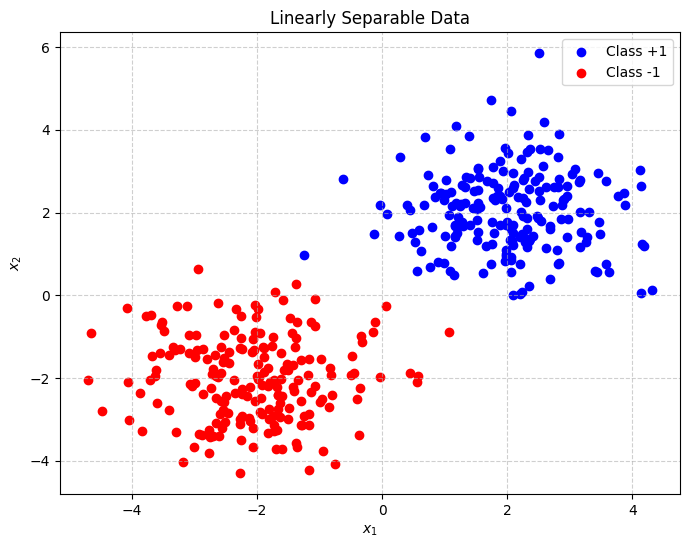

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate handmade linearly separable data
# Class 1: centered around (2, 2)
class_1 = np.random.randn(200, 2) + np.array([2, 2])
# Class -1: centered around (-2, -2)
class_neg1 = np.random.randn(200, 2) + np.array([-2, -2])

# Labels
y1 = np.ones(len(class_1))
y_neg1 = -np.ones(len(class_neg1))

X = np.vstack((class_1, class_neg1))
y = np.hstack((y1, y_neg1))

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(class_1[:, 0], class_1[:, 1], c='blue', label='Class +1')
plt.scatter(class_neg1[:, 0], class_neg1[:, 1], c='red', label='Class -1')
plt.title('Linearly Separable Data')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Part 2: Hard-Margin SVM (Primal Problem)


### Theory
We want to find a hyperplane defined by $w^T x + w_0 = 0$.
To maximize the margin, we need to minimize the magnitude of the weight vector $||w||$.

**The Optimization Problem:**
$$ \min_{w, w_0} \frac{1}{2} ||w||^2 $$
Subject to the constraints that all points are correctly classified:
$$ y_n (w^T x_n + w_0) \geq 1, \quad n = 1, \dots, N $$

*   If $y_n = 1$, we want $w^T x_n + w_0 \geq 1$.
*   If $y_n = -1$, we want $w^T x_n + w_0 \leq -1$.

---

## Part 3: Dual Formulation & The Kernel Trick Setup


### Theory
Solving the primal problem directly is difficult when we want to use kernels. Instead, we use the **Lagrangian** method to convert it into a **Dual Problem**.

By introducing Lagrange multipliers $\alpha_n \geq 0$, we derive the dual problem:

$$ \max_{\alpha} \sum_{n=1}^{N} \alpha_n - \frac{1}{2} \sum_{n=1}^{N} \sum_{m=1}^{N} \alpha_n \alpha_m y_n y_m (x_n^T x_m) $$

**Subject to:**
1.  $\sum_{n=1}^{N} \alpha_n y_n = 0$
2.  $\alpha_n \geq 0$ for all $n$

**Why is this useful?**
Notice that the data points $x$ only appear as a dot product $x_n^T x_m$. This allows us to replace the dot product with a Kernel function $K(x_n, x_m)$ later to handle non-linear data.

---

## Part 4: Implementation from Scratch (Quadratic Programming)


To solve the Dual problem, we need a Quadratic Programming (QP) solver. We will use `cvxopt`, a popular library for convex optimization.

**The QP Standard Form:**
$$ \min_{x} \frac{1}{2} x^T P x + q^T x $$
$$ \text{Subject to: } Gx \leq h, \quad Ax = b $$

Mapping our SVM Dual problem to this form:
*   $x$ becomes $\alpha$.
*   $P_{nm} = y_n y_m (x_n^T x_m)$
*   $q = -1$ (vector of -1s)
*   $G = -I$ (Identity matrix for $\alpha \geq 0$)
*   $h = 0$
*   $A = y$ (Labels vector)
*   $b = 0$

### Code Implementation


In [9]:
import numpy as np

class SVM:
    def __init__(self, C=1.0, tol=1e-3, max_iter=1000):
        """
        C: Regularization parameter (Soft Margin). 
           For Hard Margin, set C to a very large number (e.g., 1e10).
        tol: Tolerance for numerical precision (KKT conditions).
        max_iter: Maximum number of passes over the dataset.
        """
        self.C = C
        self.tol = tol
        self.max_iter = max_iter
        self.alphas = None
        self.w = None
        self.b = None
        self.support_vectors = None
        self.support_labels = None
        self.support_alphas = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize alphas and bias
        self.alphas = np.zeros(n_samples)
        self.b = 0
        
        # Precompute the Gram Matrix (Kernel Matrix) for linear kernel
        # K[i, j] = X[i] . X[j]
        K = np.dot(X, X.T)
        
        # SMO Algorithm Loop
        iter = 0
        while iter < self.max_iter:
            alphas_prev = np.copy(self.alphas)
            for i in range(n_samples):
                # Calculate Error for sample i
                # E_i = f(x_i) - y_i
                f_xi = np.sum(self.alphas * y * K[:, i]) + self.b
                E_i = f_xi - y[i]
                
                # Check KKT conditions
                # If (y_i * E_i < -tol and alpha_i < C) OR (y_i * E_i > tol and alpha_i > 0)
                if ((y[i] * E_i < -self.tol and self.alphas[i] < self.C) or 
                    (y[i] * E_i > self.tol and self.alphas[i] > 0)):
                    
                    # Select a second random index j != i
                    j = np.random.randint(0, n_samples)
                    while j == i:
                        j = np.random.randint(0, n_samples)
                    
                    # Calculate Error for sample j
                    f_xj = np.sum(self.alphas * y * K[:, j]) + self.b
                    E_j = f_xj - y[j]
                    
                    # Save old alphas
                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]
                    
                    # Compute L and H (bounds for alpha_j)
                    if y[i] != y[j]:
                        L = max(0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0, self.alphas[i] + self.alphas[j] - self.C)
                        H = min(self.C, self.alphas[i] + self.alphas[j])
                    
                    if L == H:
                        continue
                    
                    # Compute eta (the second derivative of the objective function)
                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue
                    
                    # Update alpha_j
                    self.alphas[j] -= (y[j] * (E_i - E_j)) / eta
                    
                    # Clip alpha_j to bounds [L, H]
                    self.alphas[j] = min(H, max(L, self.alphas[j]))
                    
                    # Check if change is significant
                    if abs(self.alphas[j] - alpha_j_old) < 1e-5:
                        continue
                    
                    # Update alpha_i based on alpha_j
                    self.alphas[i] += y[i] * y[j] * (alpha_j_old - self.alphas[j])
                    
                    # Compute bias b
                    b1 = self.b - E_i - y[i] * (self.alphas[i] - alpha_i_old) * K[i, i] - \
                         y[j] * (self.alphas[j] - alpha_j_old) * K[i, j]
                    b2 = self.b - E_j - y[i] * (self.alphas[i] - alpha_i_old) * K[i, j] - \
                         y[j] * (self.alphas[j] - alpha_j_old) * K[j, j]
                    
                    # Update b based on the new alphas
                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2
            
            # Check for convergence
            diff = np.linalg.norm(self.alphas - alphas_prev)
            if diff < self.tol:
                break
            iter += 1
            
        # Store Support Vectors
        sv_idx = self.alphas > 1e-5
        self.support_alphas = self.alphas[sv_idx]
        self.support_vectors = X[sv_idx]
        self.support_labels = y[sv_idx]
        
        # Calculate Weight vector w (only for linear kernel)
        self.w = np.zeros(n_features)
        for i in range(len(self.support_alphas)):
            self.w += self.support_alphas[i] * self.support_labels[i] * self.support_vectors[i]
            
        print(f"Training complete. Iterations: {iter}")
        print(f"Number of Support Vectors: {len(self.support_alphas)}")

    def predict(self, X):
        # Decision function: sign(w^T x + b)
        return np.sign(np.dot(X, self.w) + self.b)

    def decision_function(self, X):
        return np.dot(X, self.w) + self.b


## Part 5: Training and Visualizing the Result

Now, let's train our custom SVM on the handmade data and visualize the decision boundary and margins.

### Code: Training and Plotting


Training complete. Iterations: 13
Number of Support Vectors: 21
Weight vector w: [0.76626952 0.75629231]
Bias term b: -0.4145451786886663


C:\Users\taha\AppData\Local\Temp\ipykernel_25968\899587099.py:31: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='green', label='Decision Boundary')
C:\Users\taha\AppData\Local\Temp\ipykernel_25968\899587099.py:33: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx, yy, Z, levels=[-1, 1], linestyles='--', colors='gray', alpha=0.8, label='Margins')


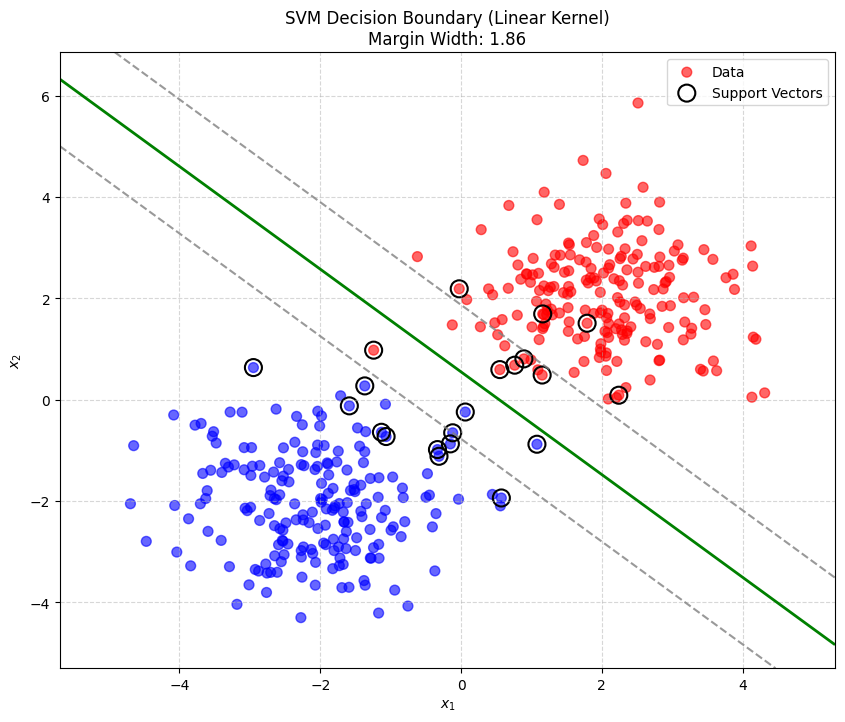

In [10]:
# Initialize and train
svm = SVM()
svm.fit(X, y)

print(f"Weight vector w: {svm.w}")
print(f"Bias term b: {svm.b}")

# --- Visualization Function ---
def plot_svm_decision_boundary(model, X, y):
    plt.figure(figsize=(10, 8))
    
    # Plot data points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.6, s=50, label='Data')
    
    # Highlight Support Vectors
    plt.scatter(model.support_vectors[:, 0], model.support_vectors[:, 1], 
                s=150, facecolors='none', edgecolors='k', linewidths=1.5, label='Support Vectors')
    
    # Create grid to evaluate model
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Decision boundary
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot contours
    # Decision boundary (w^T x + b = 0)
    plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='green', label='Decision Boundary')
    # Margins (w^T x + b = 1 and w^T x + b = -1)
    plt.contour(xx, yy, Z, levels=[-1, 1], linestyles='--', colors='gray', alpha=0.8, label='Margins')
    
    plt.title(f'SVM Decision Boundary (Linear Kernel)\nMargin Width: {2/np.linalg.norm(model.w):.2f}')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_svm_decision_boundary(svm, X, y)

## Part 6: Mathematical Verification

Let's verify the math manually for one of the support vectors.
The condition for a support vector is:
$$ y_n (w^T x_n + b) = 1 $$

### Code: Verification


In [11]:
# Pick the first support vector
sv_x = svm.support_vectors[0]
sv_y = svm.support_labels[0]

prediction = np.dot(svm.w, sv_x) + svm.b
result = sv_y * prediction

print(f"Support Vector: {sv_x}")
print(f"Label: {sv_y}")
print(f"w^T x + b = {prediction:.4f}")
print(f"y * (w^T x + b) = {result:.4f}")
print("Should be close to 1.0 (within numerical error).")

Support Vector: [2.24196227 0.08671976]
Label: 1.0
w^T x + b = 1.3690
y * (w^T x + b) = 1.3690
Should be close to 1.0 (within numerical error).


## Part 7: Nonlinear SVM and Kernel Trick (Concept)


### Theory
What if the data is not linearly separable? (e.g., one class inside a circle of another).
We map the data to a higher dimension $\phi(x)$ where it becomes linearly separable.
However, calculating $\phi(x)$ is expensive. The **Kernel Trick** allows us to calculate the dot product in the high-dimensional space without explicitly transforming the data:
$$ K(x_n, x_m) = \phi(x_n)^T \phi(x_m) $$

Common Kernels:
1.  **Linear**: $K(x, z) = x^T z$
2.  **Polynomial**: $K(x, z) = (x^T z + c)^d$
3.  **RBF (Gaussian)**: $K(x, z) = \exp(-\gamma ||x - z||^2)$

### Visualizing Non-Linear Data
Let's create a dataset that a linear SVM cannot solve.

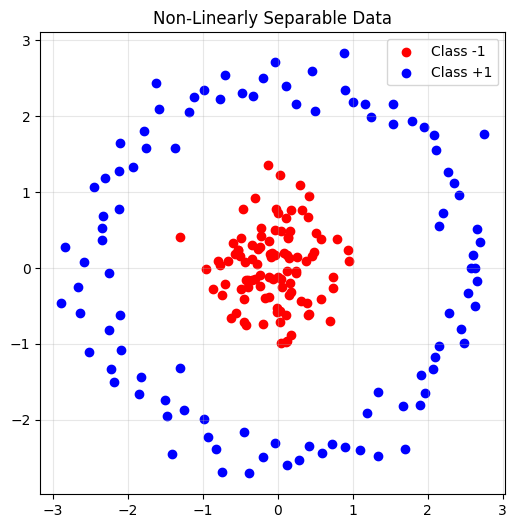

In [12]:
# Generate circular data
np.random.seed(42)
# Inner circle (Class -1)
X_inner = np.random.randn(100, 2) * 0.5
y_inner = -np.ones(100)

# Outer circle (Class +1)
theta = np.linspace(0, 2*np.pi, 100)
r = 2.5 + np.random.randn(100) * 0.2
X_outer = np.column_stack((r * np.cos(theta), r * np.sin(theta)))
y_outer = np.ones(100)

X_nonlinear = np.vstack((X_inner, X_outer))
y_nonlinear = np.hstack((y_inner, y_outer))

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(X_inner[:, 0], X_inner[:, 1], c='red', label='Class -1')
plt.scatter(X_outer[:, 0], X_outer[:, 1], c='blue', label='Class +1')
plt.title('Non-Linearly Separable Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


If you try to fit the previous `SVM` class on this `X_nonlinear`, it will fail to find a good separation. To fix this, we would modify the `fit` method to replace `np.dot(X, X.T)` with an RBF kernel matrix.

This concludes the theoretical foundation and implementation of the Linear SVM. You now have a working model that calculates the margin, identifies support vectors, and visualizes the optimal hyperplane